# 09 — LightGBM + Features Macroeconómicas

Extiende el modelo LightGBM (notebook 03) incorporando **Gold, Oil e InterestRate** como features adicionales.

La hipótesis es que los factores macro ayudan al modelo a capturar el **régimen de mercado** (subidas de tipos = presión bajista en equity, subida del oro = aversión al riesgo, etc.).

In [9]:
import sys, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from utils import (
    load_data, compute_rmse, make_submission, train_val_split,
    create_lag_features, add_calendar_features, add_log_returns, INDEX_COLS
)

data         = load_data()
train_full   = data['train_indices'][INDEX_COLS]
test_dates   = data['test_dates'].index
train, val   = train_val_split(train_full, val_size=252)

macro_train  = data['train_macro_factors']
macro_test   = data['test_macro_factors']
macro_all    = pd.concat([macro_train, macro_test]).sort_index()

MACRO_COLS = ['Gold', 'Oil', 'InterestRate']
LAGS       = (1, 2, 3, 5, 10, 20, 60)
WINDOWS    = (5, 10, 20, 60)

print(f'Train: {train.shape}  |  Val: {val.shape}  |  Test: {len(test_dates)} dias')
print(f'Macro train: {macro_train.shape}  |  Macro test: {macro_test.shape}')
print(macro_train.tail(2))
print(macro_test.head(2))

Train: (2095, 6)  |  Val: (252, 6)  |  Test: 262 dias
Macro train: (2347, 3)  |  Macro test: (262, 3)
                   Gold        Oil  InterestRate
2023-12-28  2073.899902  71.769997       0.05218
2023-12-29  2062.399902  71.650002       0.05180
                   Gold        Oil  InterestRate
2024-01-01  2062.399902  71.650002       0.05180
2024-01-02  2064.399902  70.379997       0.05213


## 1 — Feature engineering con macro

In [10]:
def build_features_macro(indices, macro_slice):
    """Lag + rolling de precios + lag + rolling de macro + calendario."""
    df = indices[INDEX_COLS].copy()
    df = add_log_returns(df)
    df = create_lag_features(df, lags=LAGS, windows=WINDOWS)
    df = add_calendar_features(df)

    # Macro: solo valores conocidos ANTES del día D (shift 1 para evitar leakage)
    mac = macro_slice[MACRO_COLS].reindex(df.index).ffill().bfill()
    for col in MACRO_COLS:
        df[f'macro_{col}']       = mac[col].shift(1)                      # nivel día D-1
        df[f'macro_{col}_lag1']  = mac[col].shift(1)                      # redundante pero explícito
        df[f'macro_{col}_ret']   = mac[col].shift(1).pct_change()         # retorno D-2→D-1
        df[f'macro_{col}_roll5'] = mac[col].shift(1).rolling(5).mean()
        df[f'macro_{col}_roll20']= mac[col].shift(1).rolling(20).mean()

    return df


def prepare_xy(feats, targets):
    rename = {c: f'__t_{c}' for c in INDEX_COLS}
    combined = pd.concat([feats, targets.rename(columns=rename)], axis=1).dropna()
    tgt_cols = list(rename.values())
    return combined.drop(columns=tgt_cols).values, combined[tgt_cols].values, list(combined.drop(columns=tgt_cols).columns)


macro_tr_slice = macro_all.loc[:train.index[-1]]
feats_tr = build_features_macro(train, macro_tr_slice)
X_tr, y_tr, feature_names = prepare_xy(feats_tr, train)
print(f'Feature matrix train: {X_tr.shape}')

Feature matrix train: (2034, 210)


## 2 — Entrenamiento LightGBM

In [11]:
def train_lgbm(X, y, n_estimators=500):
    try:
        import lightgbm as lgb
        models = []
        for i, col in enumerate(INDEX_COLS):
            m = lgb.LGBMRegressor(
                n_estimators=n_estimators, learning_rate=0.05,
                num_leaves=63, subsample=0.8, colsample_bytree=0.8, verbose=-1
            )
            m.fit(X, y[:, i])
            models.append(m)
        return models, 'lgbm'
    except ImportError:
        pass
    from sklearn.ensemble import GradientBoostingRegressor
    models = [GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                        max_depth=5, subsample=0.8
                                        ).fit(X, y[:, i]) for i in range(y.shape[1])]
    return models, 'sklearn_gbr'


models_val, lib = train_lgbm(X_tr, y_tr)
print(f'Modelos entrenados ({lib}) para validacion')

Modelos entrenados (sklearn_gbr) para validacion


## 3 — Predicción autorregresiva

In [12]:
def autoreg_predict_macro(models, history, dates, macro_all, feature_names):
    history = history[INDEX_COLS].copy()
    preds = []
    for date in dates:
        # Excluir el valor macro del día actual (no disponible al predecir)
        mac_slice = macro_all.loc[macro_all.index < date]
        feats = build_features_macro(history, mac_slice)
        row = feats.dropna().iloc[[-1]]
        for c in feature_names:
            if c not in row.columns:
                row[c] = 0.0
        row = row[feature_names]
        y_hat = np.array([m.predict(row.values)[0] for m in models])
        preds.append(y_hat)
        new_row = pd.DataFrame([y_hat], index=[date], columns=INDEX_COLS)
        history = pd.concat([history, new_row])
    return pd.DataFrame(preds, index=dates, columns=INDEX_COLS)

## 4 — Validación local

In [13]:
print('Prediciendo en validacion (252 dias)...')
pred_val = autoreg_predict_macro(models_val, train, val.index, macro_all, feature_names)
rmse = compute_rmse(val, pred_val)
print(f'[MacroLGBM] RMSE validacion = {rmse:,.2f}')
per = np.sqrt(((val.values - pred_val.values) ** 2).mean(axis=0))
for col, r in zip(INDEX_COLS, per):
    print(f'  {col}: {r:,.2f}')

# Referencia: RMSE del modelo sin macro (del notebook 03)
print()
print('Referencia LightGBM sin macro (nb 03): ~3.279')

Prediciendo en validacion (252 dias)...
[MacroLGBM] RMSE validacion = 3,277.59
  Index_A: 3,236.41
  Index_B: 396.72
  Index_C: 1.35
  Index_D: 3,438.81
  Index_E: 9.88
  Index_F: 12,582.36

Referencia LightGBM sin macro (nb 03): ~3.279


## 5 — Importancia de features macro

In [14]:
import matplotlib.pyplot as plt

# Solo si usamos LightGBM nativo
if lib == 'lgbm':
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    macro_feature_names = [f for f in feature_names if 'macro_' in f]
    for ax, m, col in zip(axes.flatten(), models_val, INDEX_COLS):
        imp = pd.Series(m.feature_importances_, index=feature_names)
        macro_imp = imp[macro_feature_names].sort_values(ascending=False)
        macro_imp.plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'{col} — importancia features macro')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig('macro_feature_importance.png', dpi=100)
    plt.show()
else:
    print('Importancia de features disponible solo con LightGBM nativo (pip install lightgbm)')

Importancia de features disponible solo con LightGBM nativo (pip install lightgbm)


## 6 — Reentrenar con todos los datos y generar submission

In [15]:
print('Reentrenando con train completo...')
feats_full = build_features_macro(train_full, macro_all.loc[:train_full.index[-1]])
X_full, y_full, fn_full = prepare_xy(feats_full, train_full)
models_full, _ = train_lgbm(X_full, y_full)

print('Prediciendo test (262 dias autorregresivos)...')
pred_test = autoreg_predict_macro(models_full, train_full, test_dates, macro_all, fn_full)
make_submission(pred_test, 'submission_09_macro_lgbm.csv')
pred_test.head()

Reentrenando con train completo...
Prediciendo test (262 dias autorregresivos)...
Submission saved: c:\Users\1jose\Desktop\previa hackatlon\hackathon\submissions\submission_09_macro_lgbm.csv


,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
Date,,,,,,
2024-01-01,16827.153420,4769.736050,20.242498,16838.377750,129.003003,42099.130904
2024-01-02,16825.946469,4769.724125,20.243022,16841.000449,129.059841,42081.691589
2024-01-03,16822.771269,4770.130854,20.243135,16840.062148,129.022455,42080.077868
2024-01-04,16824.630007,4770.035137,20.242702,16838.517915,129.029799,42076.802109
2024-01-05,16824.576664,4769.974049,20.243659,16841.639229,128.981407,42080.995362


## 7 — Visualización: predicción vs tendencia real

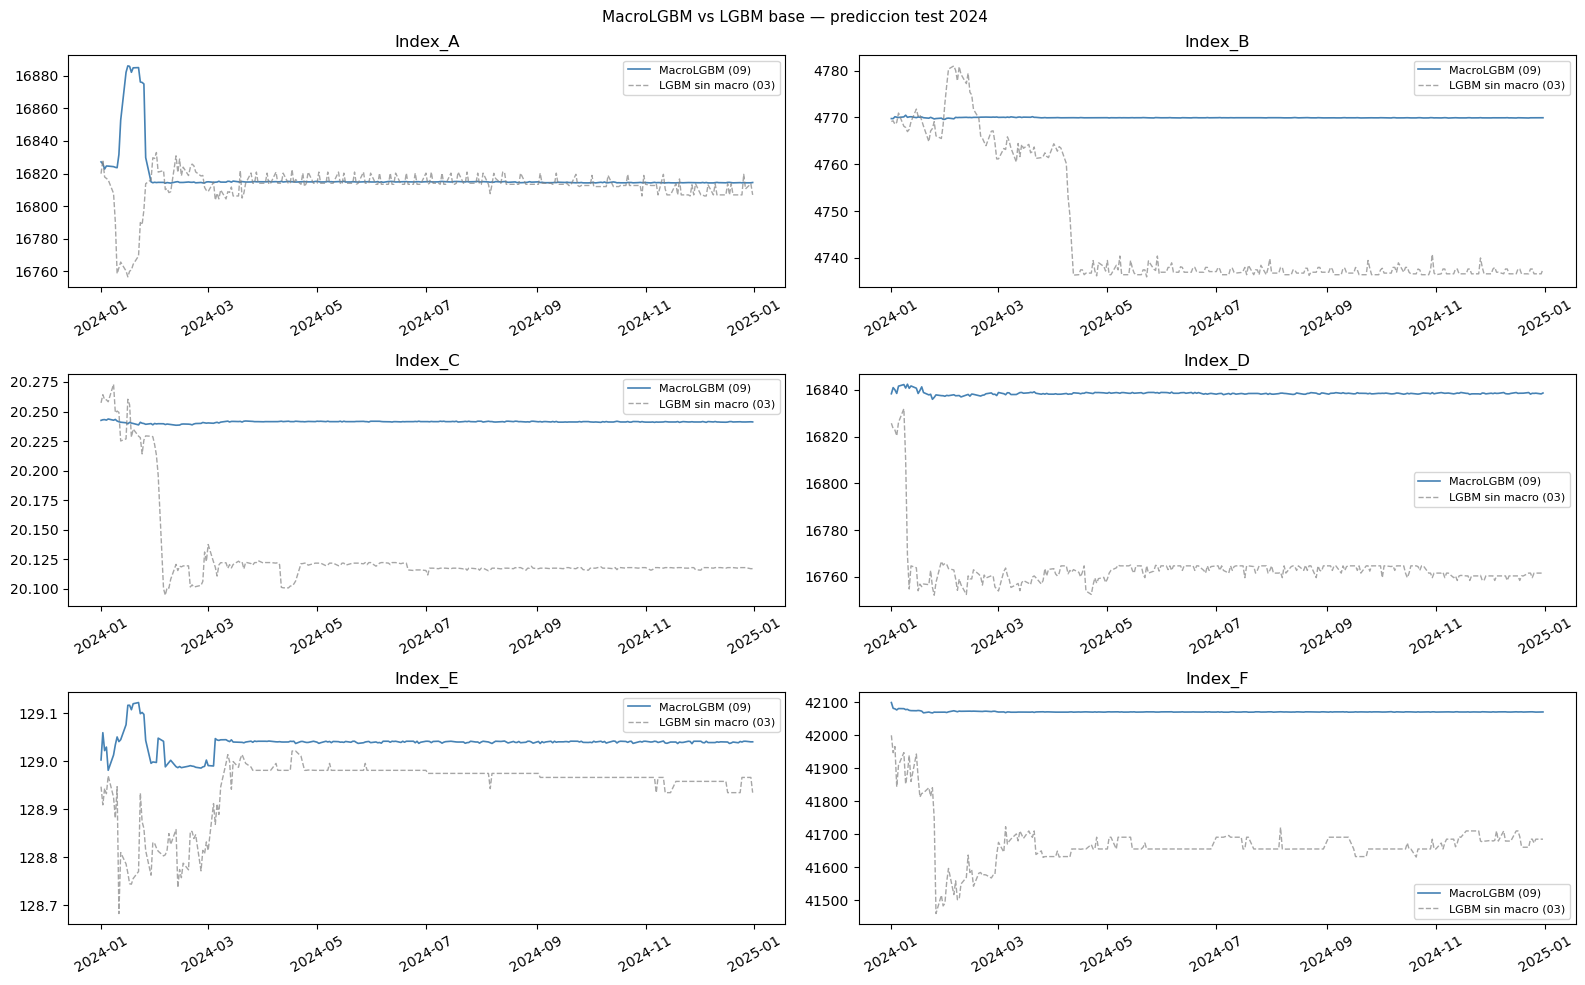

In [16]:
# Cargar submission 03 (sin macro) para comparar visualmente
import os
sub03_path = os.path.join('submissions', 'submission_03_lgbm.csv')
if os.path.exists(sub03_path):
    sub03 = pd.read_csv(sub03_path, parse_dates=[0], index_col=0).reindex(test_dates)[INDEX_COLS]

    fig, axes = plt.subplots(3, 2, figsize=(16, 10))
    for ax, col in zip(axes.flatten(), INDEX_COLS):
        ax.plot(test_dates, pred_test[col], label='MacroLGBM (09)', color='steelblue', lw=1.2)
        ax.plot(test_dates, sub03[col], label='LGBM sin macro (03)', color='gray',
                lw=1.0, linestyle='--', alpha=0.7)
        ax.set_title(col)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('MacroLGBM vs LGBM base — prediccion test 2024', fontsize=11)
    plt.tight_layout()
    plt.savefig('macro_lgbm_vs_base.png', dpi=100)
    plt.show()
else:
    print('Ejecuta primero 03_LightGBM.ipynb para tener la referencia')